# Map of bin averages
This notebook computes binned averages of any variable present in SWOT Expert files and plots maps.

It uses swot_analysis.binned_mean as main library.

In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert
import swot_analysis.binned_mean as bm

# ── Dask ─────────────────────────────────────────────────────────────────────
import dask
import dask.bag as db
from dask.distributed import Client, LocalCluster, progress, wait

from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert 

In [2]:
# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -60.0,60.0
LON_MIN, LON_MAX = 0.0,360.0
BOX_DEG = 1.0
VARIABLE = ['ssha_karin_2','swh_karin']
HRET = True

# ── Dask cluster parameters ───────────────────────────────────────────────────
N_WORKERS          = 4       # number of worker processes
THREADS_PER_WORKER = 1       # do NOT increase, core functions contain lops
MEMORY_LIMIT       = '4GB'   # per worker RAM cap

# ── Files information ────────────────────────────────────────────────────────
DATA_DIR = '/Volumes/PortableSSD/'

# ── One sub-directory per month of SWOT data ────────────────────────────────
# Every file found under each entry is tagged with the (year, month) inferred
# from that sub-directory's name (see parse_year_month below).
DATA_SUBDIRS = ['SWOT_L2_LR_SSH_Expert_0124/',
                'SWOT_L2_LR_SSH_Expert_0224/',
                #'SWOT_L2_LR_SSH_Expert_0324/',
               #'SWOT_L2_LR_SSH_Expert_0424/',
               #'SWOT_L2_LR_SSH_Expert_0524/',
               #'SWOT_L2_LR_SSH_Expert_0624/',
               #'SWOT_L2_LR_SSH_Expert_0724/',
               #'SWOT_L2_LR_SSH_Expert_0824/',
               #'SWOT_L2_LR_SSH_Expert_0924/',
               #'SWOT_L2_LR_SSH_Expert_1024/',
               #'SWOT_L2_LR_SSH_Expert_1124/',
               #'SWOT_L2_LR_SSH_Expert_1224/',
               ]
FILE_PATTERN = 'SWOT_L2_LR_SSH_Expert_*.nc'
for subdir in DATA_SUBDIRS:
    files = sorted(glob.glob(DATA_DIR+FILE_PATTERN, recursive=True))
    print(f'{len(files)} files found in directory.')

0 files found in directory.
0 files found in directory.


In [3]:
import re

def parse_year_month(subdir_name, overrides=None):
    """
    Infer (year, month) from a sub-directory name.

    Default rule: the trailing 4 digits are read as MMYY, e.g.
    'SWOT_L2_0225' -> month=2, year=2025.

    For directories that don't follow this convention, pass a dict via
    `overrides` mapping subdir name -> (year, month); it takes precedence
    over the automatic parsing.
    """
    if overrides and subdir_name in overrides:
        return overrides[subdir_name]
    name = subdir_name.rstrip('/').rstrip('\\')
    match = re.search(r'(\d{2})(\d{2})$', name)
    if not match:
        raise ValueError(
            f"Could not infer year/month from subdirectory name '{subdir_name}'. "
            f"Add an explicit entry to DATA_SUBDIR_OVERRIDES instead."
        )
    mm, yy = match.groups()
    month = int(mm)
    year = 2000 + int(yy)
    if not (1 <= month <= 12):
        raise ValueError(f"Parsed invalid month={month} from '{subdir_name}'.")
    return year, month

# Manual overrides for sub-directories that don't follow the MMYY naming
# convention above, e.g. {'my_weird_folder_name': (2025, 7)}
DATA_SUBDIR_OVERRIDES = {}

In [4]:
cluster = LocalCluster(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    dashboard_address=':8787',
)
client = Client(cluster)
print(f"Dashboard: {client.dashboard_link}")
client   # displays the interactive widget in JupyterLab

Dashboard: http://127.0.0.1:8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:59508,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:59519,Total threads: 1
Dashboard: http://127.0.0.1:59523/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:59511,


## Worker function

In [5]:
def worker(filepaths):
    import numpy as np
    import xarray as xr
    import traceback as _tb
    from swot_analysis import load_swot_l2_expert
    from swot_analysis import compute_pass_spectra
    from pathlib import Path
    
    acc = bm.SWOTGridAccumulator(
    variables=VARIABLE,
    dlat=BOX_DEG,
    dlon=BOX_DEG,
    HRET=HRET,
    )
    acc.add_file(filepaths)
    return acc
#acc = bm.SWOTGridAccumulator(dlat=BOX_DEG, dlon=BOX_DEG)
#    acc.add_file(filepaths,variables=VARIABLE,HRET=HRET,)
#    return acc

## Computation

In [6]:
filepaths = []
file_year_month = []

for subdir in DATA_SUBDIRS:
    year, month = parse_year_month(subdir, overrides=DATA_SUBDIR_OVERRIDES)
    subdir_files = sorted(glob.glob(os.path.join(DATA_DIR, subdir, FILE_PATTERN)))
    print(f'{subdir:30s} -> {len(subdir_files):4d} files  (year={year}, month={month:02d})')
    filepaths.extend(subdir_files)
    file_year_month.extend([(year, month)] * len(subdir_files))
    
    
#wait(futures)

SWOT_L2_LR_SSH_Expert_0124/    ->  865 files  (year=2024, month=01)
SWOT_L2_LR_SSH_Expert_0224/    ->  809 files  (year=2024, month=02)


In [7]:
futures = client.map(worker,filepaths,)

progress(futures)

VBox()

In [8]:
# Gather results back to the main process
results = client.gather(futures)

In [9]:
acc = results[0]
for other in results[1:]:
    acc += other

ds = acc.to_dataset()
ds

<xarray.Dataset> Size: 1MB
Dimensions:            (latitude: 120, longitude: 360)
Coordinates:
  * latitude           (latitude) float64 960B -59.5 -58.5 -57.5 ... 58.5 59.5
  * longitude          (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
Data variables:
    mean_ssha_karin_2  (latitude, longitude) float64 346kB 0.01492 ... -0.04178
    nobs_ssha_karin_2  (latitude, longitude) int64 346kB 16052 15866 ... 14506
    mean_swh_karin     (latitude, longitude) float64 346kB 4.215 4.388 ... 3.072
    nobs_swh_karin     (latitude, longitude) int64 346kB 16007 15710 ... 14351

## Visualisation

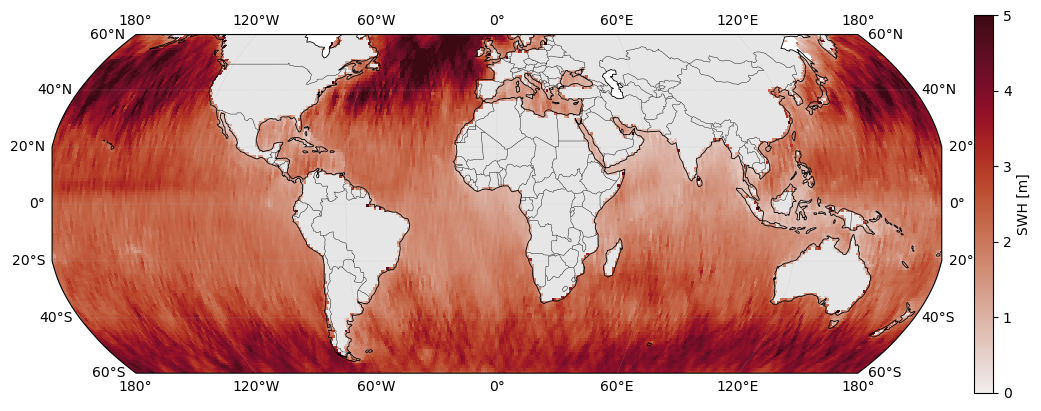

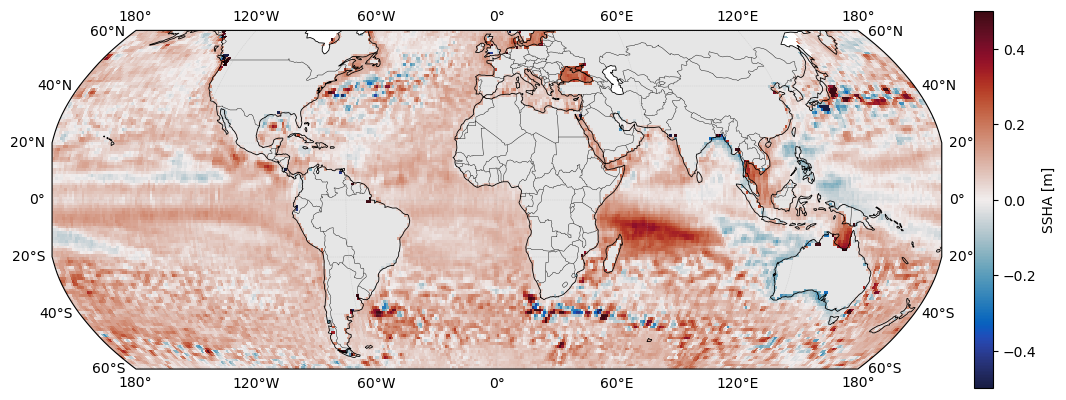

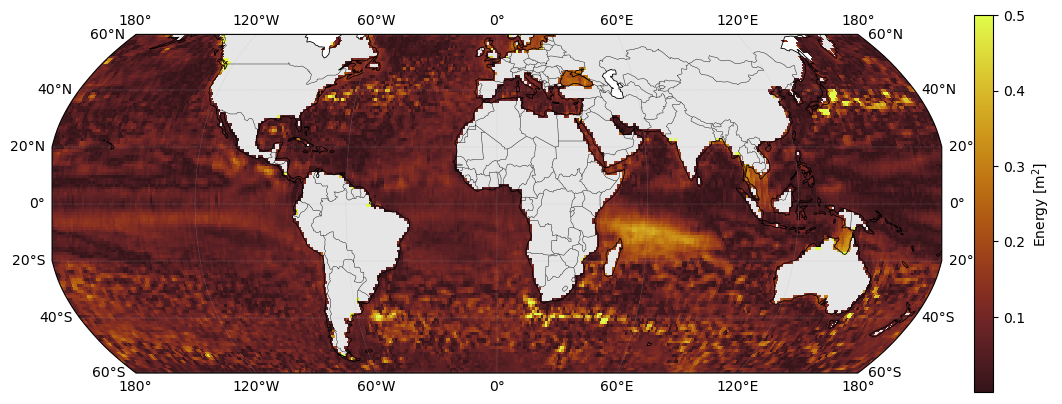

In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import cmocean as cm

projection = ccrs.Robinson()
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=projection)
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)

sc = ds.mean_swh_karin.plot(ax=ax,vmax=5,transform=ccrs.PlateCarree(),add_colorbar=False,cmap=cm.cm.amp
                          )
cb = plt.colorbar(sc,ax=ax,shrink=0.7,pad=0.03)
cb.set_label('SWH [m]')
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=projection)
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)

sc = ds.mean_ssha_karin_2.plot(ax=ax,vmax=0.5,transform=ccrs.PlateCarree(),add_colorbar=False,cmap=cm.cm.balance
                          )
cb = plt.colorbar(sc,ax=ax,shrink=0.7,pad=0.03)
cb.set_label('SSHA [m]')
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=projection)
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)

sc = np.sqrt(ds.mean_ssha_karin_2**2).plot(ax=ax,vmax=0.5,transform=ccrs.PlateCarree(),add_colorbar=False,cmap=cm.cm.solar
                          )
cb = plt.colorbar(sc,ax=ax,shrink=0.7,pad=0.03)
cb.set_label(r'Energy [m$^2$]')
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

In [12]:
client.close()
cluster.close()